     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ENVIRONMENT CHECK
Ultralytics version: 8.4.135
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8

DATASET CONFIGURATION
Dataset YAML:
/content/drive/MyDrive/WorkerSafety25_augmented_5cls/data.yaml
YAML exists: True
Validation directory:
/content/drive/MyDrive/WorkerSafety25_augmented_5cls/valid/images
Validation directory exists: True

YOLO BASELINE SETUP
Model: yolov8n.pt
Model loaded successfully ✅
Device: 0

VALIDA

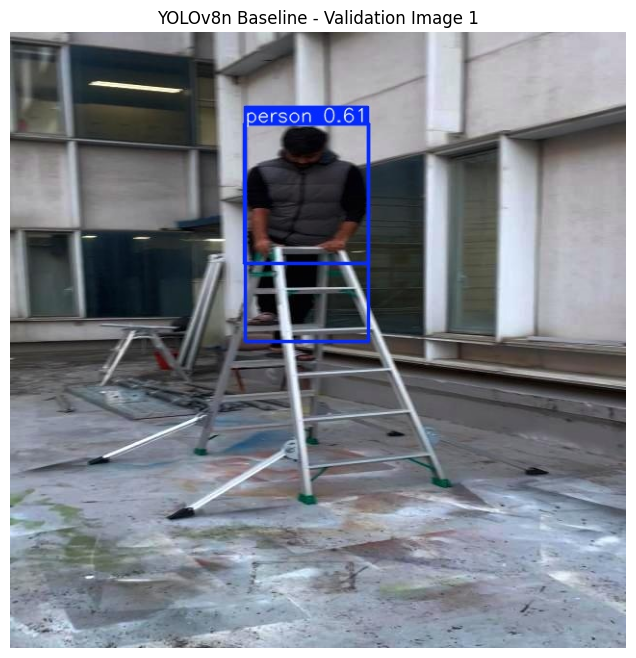

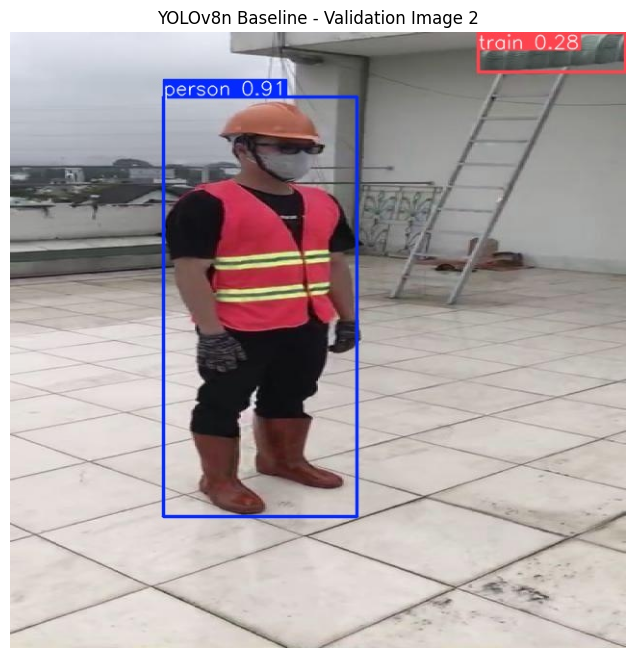

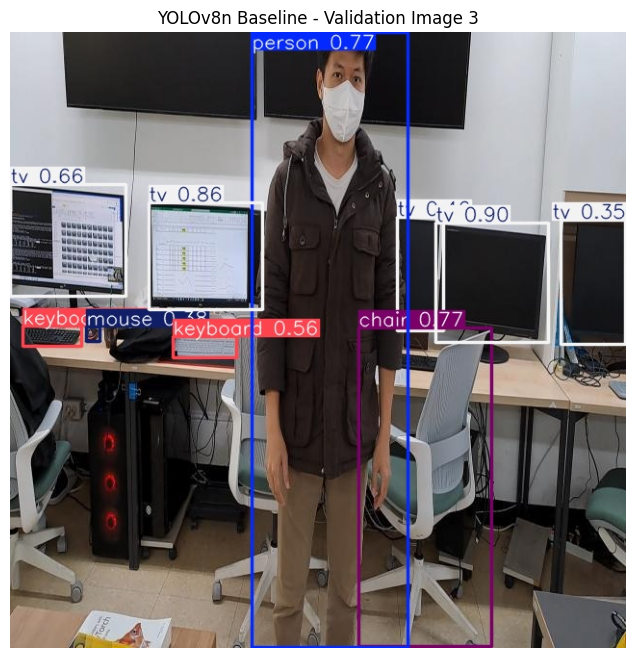

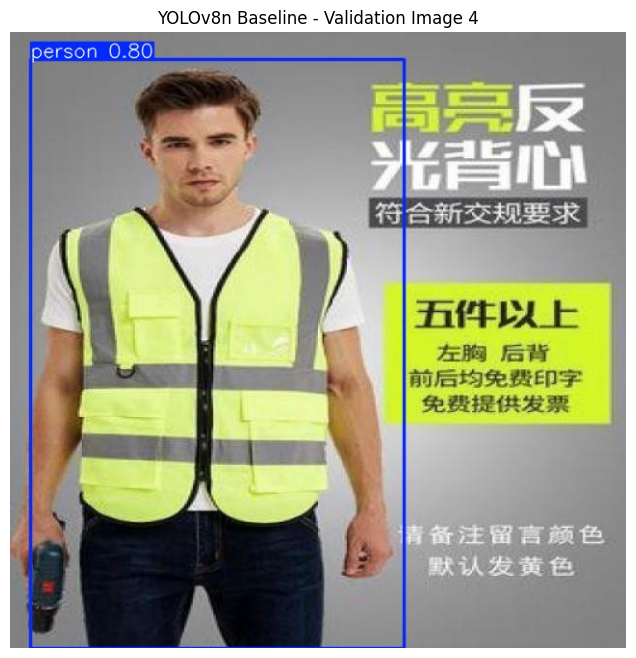


FINAL SUMMARY
YOLO model: yolov8n.pt
Dataset: /content/drive/MyDrive/WorkerSafety25_augmented_5cls/data.yaml
Validation images available: 1093
Validation images tested: 20
Image size: 640
Device: 0
Total detections: 61

✅ YOLO baseline pipeline check completed successfully.
✅ Initial validation functionality check completed.


In [1]:
# ============================================================
# WorkerSafety25 - Model Development Baseline
# YOLOv8n Pretrained Model
# ============================================================
!pip install ultralytics
# ============================================================
import os
import glob
import random
import torch
import ultralytics
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_YAML = "/content/drive/MyDrive/WorkerSafety25_augmented_5cls/data.yaml"

MODEL_NAME = "yolov8n.pt"

VAL_IMAGES = "/content/drive/MyDrive/WorkerSafety25_augmented_5cls/valid/images"

OUTPUT_DIR = "/content/drive/MyDrive/WorkerSafety25_augmented_5cls/baseline_val_check"

NUM_VALIDATION_IMAGES = 20

IMAGE_SIZE = 640

CONFIDENCE = 0.25


# ============================================================
# 2. ENVIRONMENT CHECK
# ============================================================

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    DEVICE = 0
else:
    print("⚠️ GPU NOT AVAILABLE")
    DEVICE = "cpu"


# ============================================================
# 3. DATASET CONFIGURATION CHECK
# ============================================================

print("\n" + "=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)

print("Dataset YAML:")
print(DATA_YAML)

print("YAML exists:", os.path.exists(DATA_YAML))

print("Validation directory:")
print(VAL_IMAGES)

print("Validation directory exists:", os.path.exists(VAL_IMAGES))


# ============================================================
# 4. LOAD PRETRAINED YOLOv8n
# ============================================================

print("\n" + "=" * 60)
print("YOLO BASELINE SETUP")
print("=" * 60)

model = YOLO(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Model loaded successfully ✅")
print("Device:", DEVICE)


# ============================================================
# 5. VALIDATION SUBSET
# ============================================================

print("\n" + "=" * 60)
print("VALIDATION SUBSET")
print("=" * 60)

image_paths = glob.glob(
    os.path.join(VAL_IMAGES, "*.jpg")
)

print("Validation images found:", len(image_paths))

random.seed(42)

subset = random.sample(
    image_paths,
    min(NUM_VALIDATION_IMAGES, len(image_paths))
)

print("Images selected:", len(subset))


# ============================================================
# 6. INITIAL FUNCTIONALITY CHECK
# ============================================================

print("\n" + "=" * 60)
print("INITIAL FUNCTIONALITY CHECK")
print("=" * 60)

os.makedirs(OUTPUT_DIR, exist_ok=True)

results = model.predict(
    source=subset,
    device=DEVICE,
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE,
    save=True,
    project=OUTPUT_DIR,
    name="results",
    exist_ok=True,
    verbose=True
)


# ============================================================
# 7. INFERENCE SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FUNCTIONALITY CHECK COMPLETE")
print("=" * 60)

print("Images tested:", len(results))

print("Results saved to:")
print(os.path.join(OUTPUT_DIR, "results"))


# ============================================================
# 8. BASIC DETECTION SUMMARY
# ============================================================

total_detections = 0

for result in results:
    if result.boxes is not None:
        total_detections += len(result.boxes)

print("\nTotal detections:", total_detections)


# ============================================================
# 9. VISUAL CHECK - FIRST 4 RESULTS
# ============================================================

RESULTS_DIR = os.path.join(
    OUTPUT_DIR,
    "results"
)

result_images = glob.glob(
    os.path.join(RESULTS_DIR, "*.jpg")
)

print("\n" + "=" * 60)
print("VISUAL CHECK")
print("=" * 60)

print("Result images found:", len(result_images))

for i, img_path in enumerate(result_images[:4]):

    img = Image.open(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"YOLOv8n Baseline - Validation Image {i+1}"
    )
    plt.show()


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("YOLO model:", MODEL_NAME)
print("Dataset:", DATA_YAML)
print("Validation images available:", len(image_paths))
print("Validation images tested:", len(subset))
print("Image size:", IMAGE_SIZE)
print("Device:", DEVICE)
print("Total detections:", total_detections)

print("\n✅ YOLO baseline pipeline check completed successfully.")
print("✅ Initial validation functionality check completed.")